In [ ]:
%pip install numpy 
%pip install matplotlib 
%pip install seaborn 
%pip install pandas 

In [ ]:
import numpy as np 
import matplotlib.pyplot as mlt
import pandas as pd 
import warnings 
import seaborn as sns
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_csv("insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# EDA - Starts From Here

In [8]:
df.shape

(1338, 7)

In [11]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [13]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


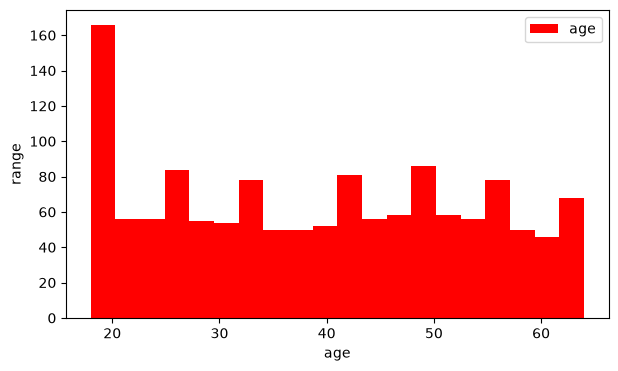

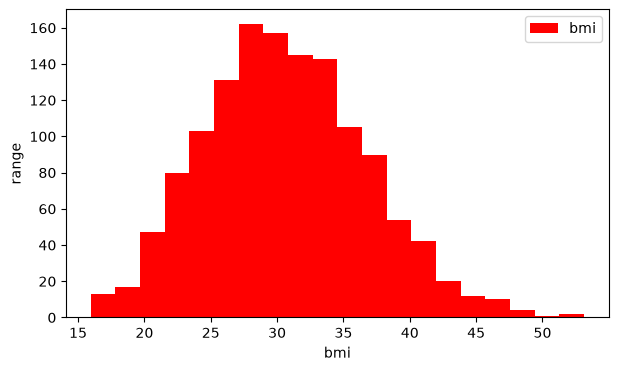

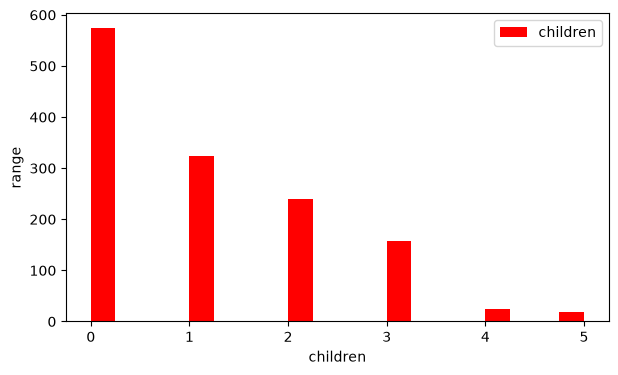

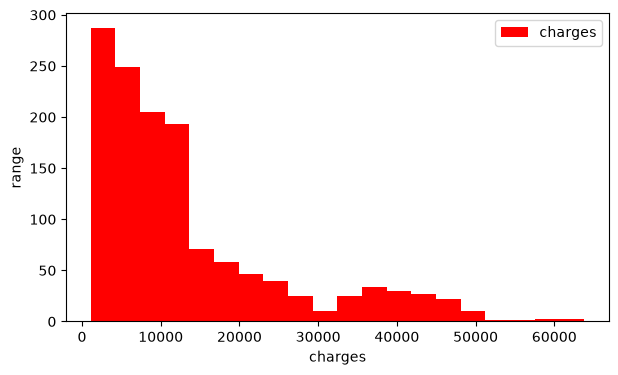

In [28]:
# now getting numeric colums for ploting them
numeric_colums = ["age" , "bmi" , "children" , "charges"]
for col in numeric_colums:
    mlt.figure(figsize=(7,4));
    mlt.hist(df[col],bins=20 , label=(col) , color="red");
    mlt.xlabel(col)
    mlt.ylabel("range")
    mlt.legend();
    mlt.show()

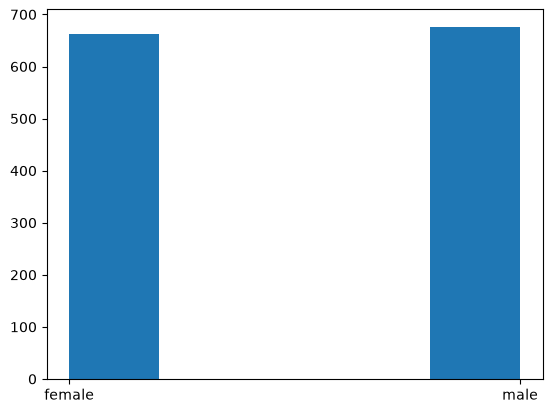

In [32]:
mlt.hist(df["sex"],bins=5)
mlt.show()

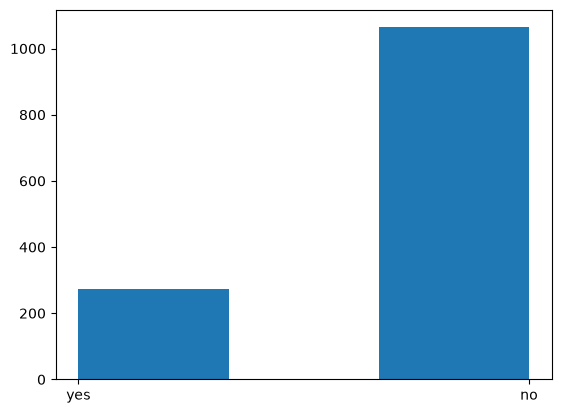

In [36]:
mlt.hist(df["smoker"],bins=3)
mlt.show()

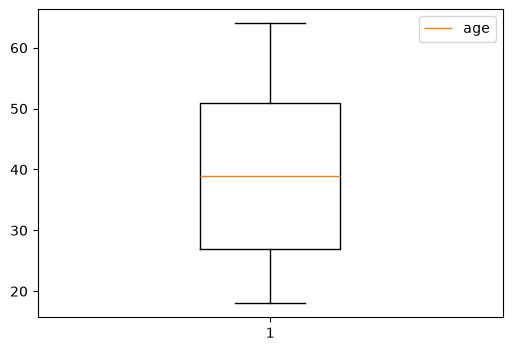

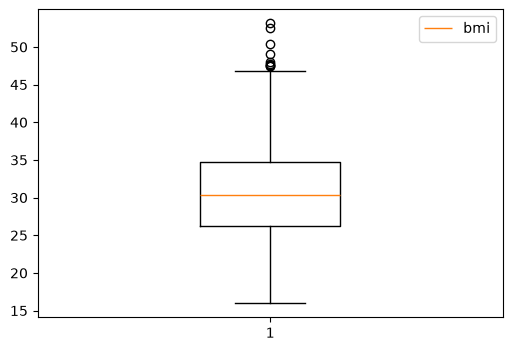

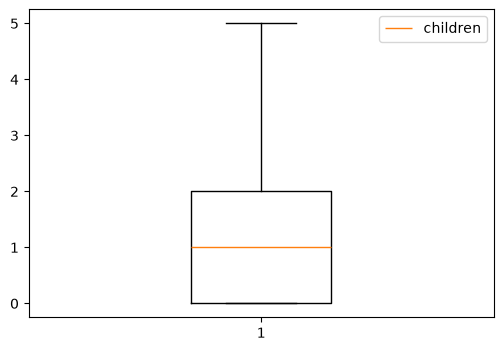

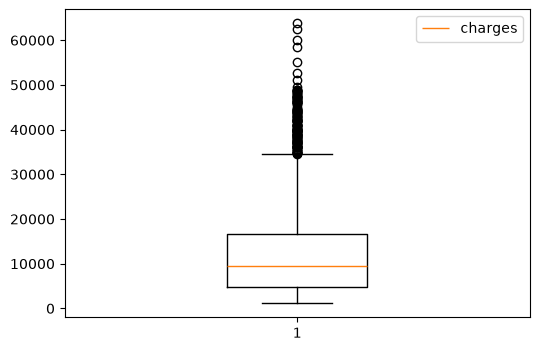

In [ ]:
for col in numeric_colums:
    mlt.figure(figsize=(6,4))
    mlt.boxplot(x = df[col] , label=(col))
    mlt.legend()
    mlt.show()

# Data Cleaning And Preprossing

In [55]:
df.isnull().sum() # result : it mean there is no null values

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [54]:
df["sex"].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [57]:
df.shape

(1338, 7)

In [ ]:
df.drop_duplicates(inplace=True) # duplicate removed

In [60]:
df.shape

(1337, 7)

In [61]:
# now convert the str into integer 
df["sex"] = df["sex"].map({"male" : 0 , "female" : 1})
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [64]:
# df["smoker"] = df["smoker"].map({"yes" : 1 , "no" : 0})
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [ ]:
df["smoker"].value_counts() 
# here is also only yes and no , and there no extra value to drop

smoker
0    1063
1     274
Name: count, dtype: int64

In [68]:
# now changing the names of columns
df.rename(columns={"sex" : "is_femail" , "smoker" : "is_smoker"} , inplace=True);
df.head()

,age,is_femail,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [ ]:
df["region"].value_counts() 
# value_count tells us that how many diffrent values are there

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [71]:
df= pd.get_dummies(df , columns=["region"])
df.head()

,age,is_femail,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,False,True
1,18,0,33.770,1,0,1725.55230,False,False,True,False
2,28,0,33.000,3,0,4449.46200,False,False,True,False
3,33,0,22.705,0,0,21984.47061,False,True,False,False
4,32,0,28.880,0,0,3866.85520,False,True,False,False


In [72]:
df = df.astype(int)
df.head()

,age,is_femail,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,0,1
1,18,0,33,1,0,1725,0,0,1,0
2,28,0,33,3,0,4449,0,0,1,0
3,33,0,22,0,0,21984,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0


# Feature Engineering and Extraction 

In [ ]:
# in Progress .... 